Found 1668 images belonging to 17 classes.
Found 408 images belonging to 17 classes.
Number of Classes: 17
Class Index: {'Avulsion fracture': 0, 'Closed(simple) fracture': 1, 'Comminuted fracture': 2, 'Compression-Crush fracture': 3, 'Fracture Dislocation': 4, 'Greenstick fracture': 5, 'Hairline Fracture': 6, 'Impacted fracture': 7, 'Intra-articular fracture': 8, 'Longitudinal fracture': 9, 'Oblique fracture': 10, 'Open(compound) fracture': 11, 'Pathological fracture': 12, 'Segmental fracture': 13, 'Spiral Fracture': 14, 'Stress fracture': 15, 'Transverse fracture': 16}


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)          │ (None, 10, 10, 1280)        │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_3           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 1280)                │           5,120 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 1024)                │       1,311,744 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 512)                 │         524,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 17)                  │           8,721 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,899,956 (22.51 MB)

 Trainable params: 5,325,957 (20.32 MB)

 Non-trainable params: 573,999 (2.19 MB)

Epoch 1/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 211s 3s/step - accuracy: 0.0881 - loss: 3.4463 - val_accuracy: 0.1324 - val_loss: 2.7651 - learning_rate: 1.0000e-04
Epoch 2/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 144s 3s/step - accuracy: 0.1523 - loss: 2.8601 - val_accuracy: 0.1544 - val_loss: 2.6789 - learning_rate: 1.0000e-04
Epoch 3/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 137s 3s/step - accuracy: 0.2002 - loss: 2.5990 - val_accuracy: 0.2010 - val_loss: 2.5580 - learning_rate: 1.0000e-04
Epoch 4/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 133s 2s/step - accuracy: 0.2380 - loss: 2.4167 - val_accuracy: 0.2426 - val_loss: 2.4556 - learning_rate: 1.0000e-04
Epoch 5/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 134s 3s/step - accuracy: 0.2884 - loss: 2.2637 - val_accuracy: 0.2549 - val_loss: 2.3922 - learning_rate: 1.0000e-04
Epoch 6/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 141s 3s/step - accuracy: 0.3159 - loss: 2.1371 - val_accuracy: 0.2745 - val_loss: 2.2926 - learning_rate: 1.0000e-04
Epoch 7/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 143s 3s/step - accuracy: 0.3459 

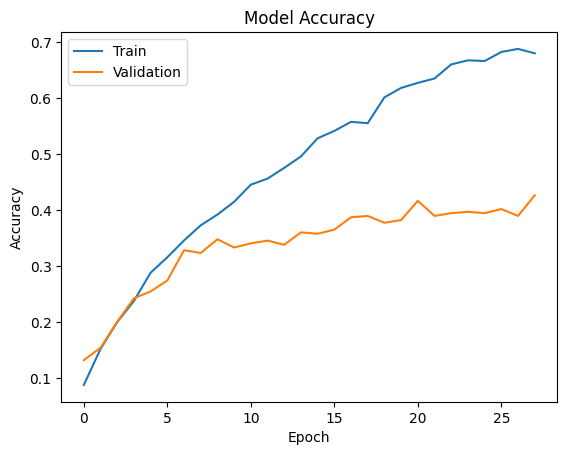

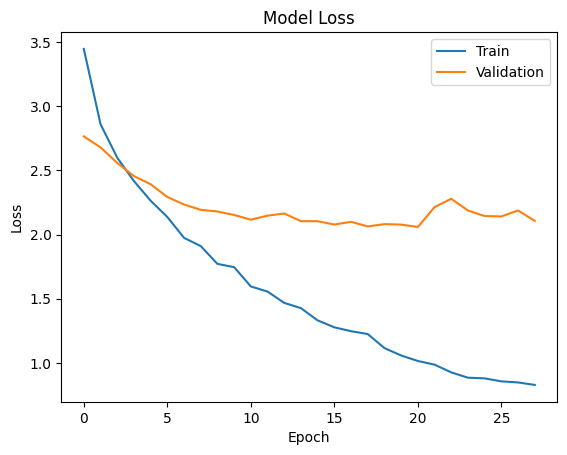

Model Saved Successfully


In [38]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import matplotlib.pyplot as plt

IMG_SIZE = 300
BATCH_SIZE = 32
EPOCHS = 50

dataset_path = "dataset"   

datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=25,
    zoom_range=0.25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest"
)

train_gen = datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training"
)

val_gen = datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation"
)

num_classes = train_gen.num_classes

print("Number of Classes:", num_classes)
print("Class Index:", train_gen.class_indices)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)

class_weights = dict(enumerate(class_weights))


base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

for layer in base_model.layers[:-100]:
    layer.trainable = False

model = models.Sequential([
    
    base_model,
    
    layers.GlobalAveragePooling2D(),
    
    layers.BatchNormalization(),
    
    layers.Dense(1024, activation="relu"),
    layers.Dropout(0.5),
    
    layers.Dense(512, activation="relu"),
    layers.Dropout(0.4),
    
    layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


early_stop = EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True
)

lr_reduce = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3,
    min_lr=1e-6
)


history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=[early_stop, lr_reduce],
    class_weight=class_weights
)

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Train", "Validation"])
plt.show()

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend(["Train", "Validation"])
plt.show()

model.save("bone_fracture_model.h5")

print("Model Saved Successfully")